✅ 已自动创建输出文件夹: time4
📊 数据加载与预处理
✅ 数据预处理完成 | 训练集: (390, 6, 1) | 测试集: (94, 6, 1)

🔍 IPSO峰值优先优化LSTM超参数
IPSO 迭代 1/15 | 最优综合损失: 0.000002 | 无提升次数: 2
IPSO 迭代 2/15 | 最优综合损失: 0.000002 | 无提升次数: 0
IPSO 迭代 3/15 | 最优综合损失: 0.000002 | 无提升次数: 10
⚠️ IPSO 已连续8次无提升，提前终止优化

✅ IPSO最优参数：
  units1=154, units2=115, dropout=0.10, batch=17, lr=0.0018

🚀 训练双向LSTM（峰值捕捉版）
Epoch 1/50
23/23 [==============================] - 7s 100ms/step - loss: 0.0166 - val_loss: 0.0010 - lr: 0.0018
Epoch 2/50
23/23 [==============================] - 1s 52ms/step - loss: 0.0091 - val_loss: 9.8930e-04 - lr: 0.0018
Epoch 3/50
23/23 [==============================] - 1s 52ms/step - loss: 0.0072 - val_loss: 1.1997e-04 - lr: 0.0018
Epoch 4/50
23/23 [==============================] - 1s 53ms/step - loss: 0.0065 - val_loss: 3.6812e-04 - lr: 0.0018
Epoch 5/50
23/23 [==============================] - 1s 52ms/step - loss: 0.0060 - val_loss: 2.5086e-06 - lr: 0.0018
Epoch 6/50
23/23 [==============================] - 1s 52ms/step - loss: 0.004

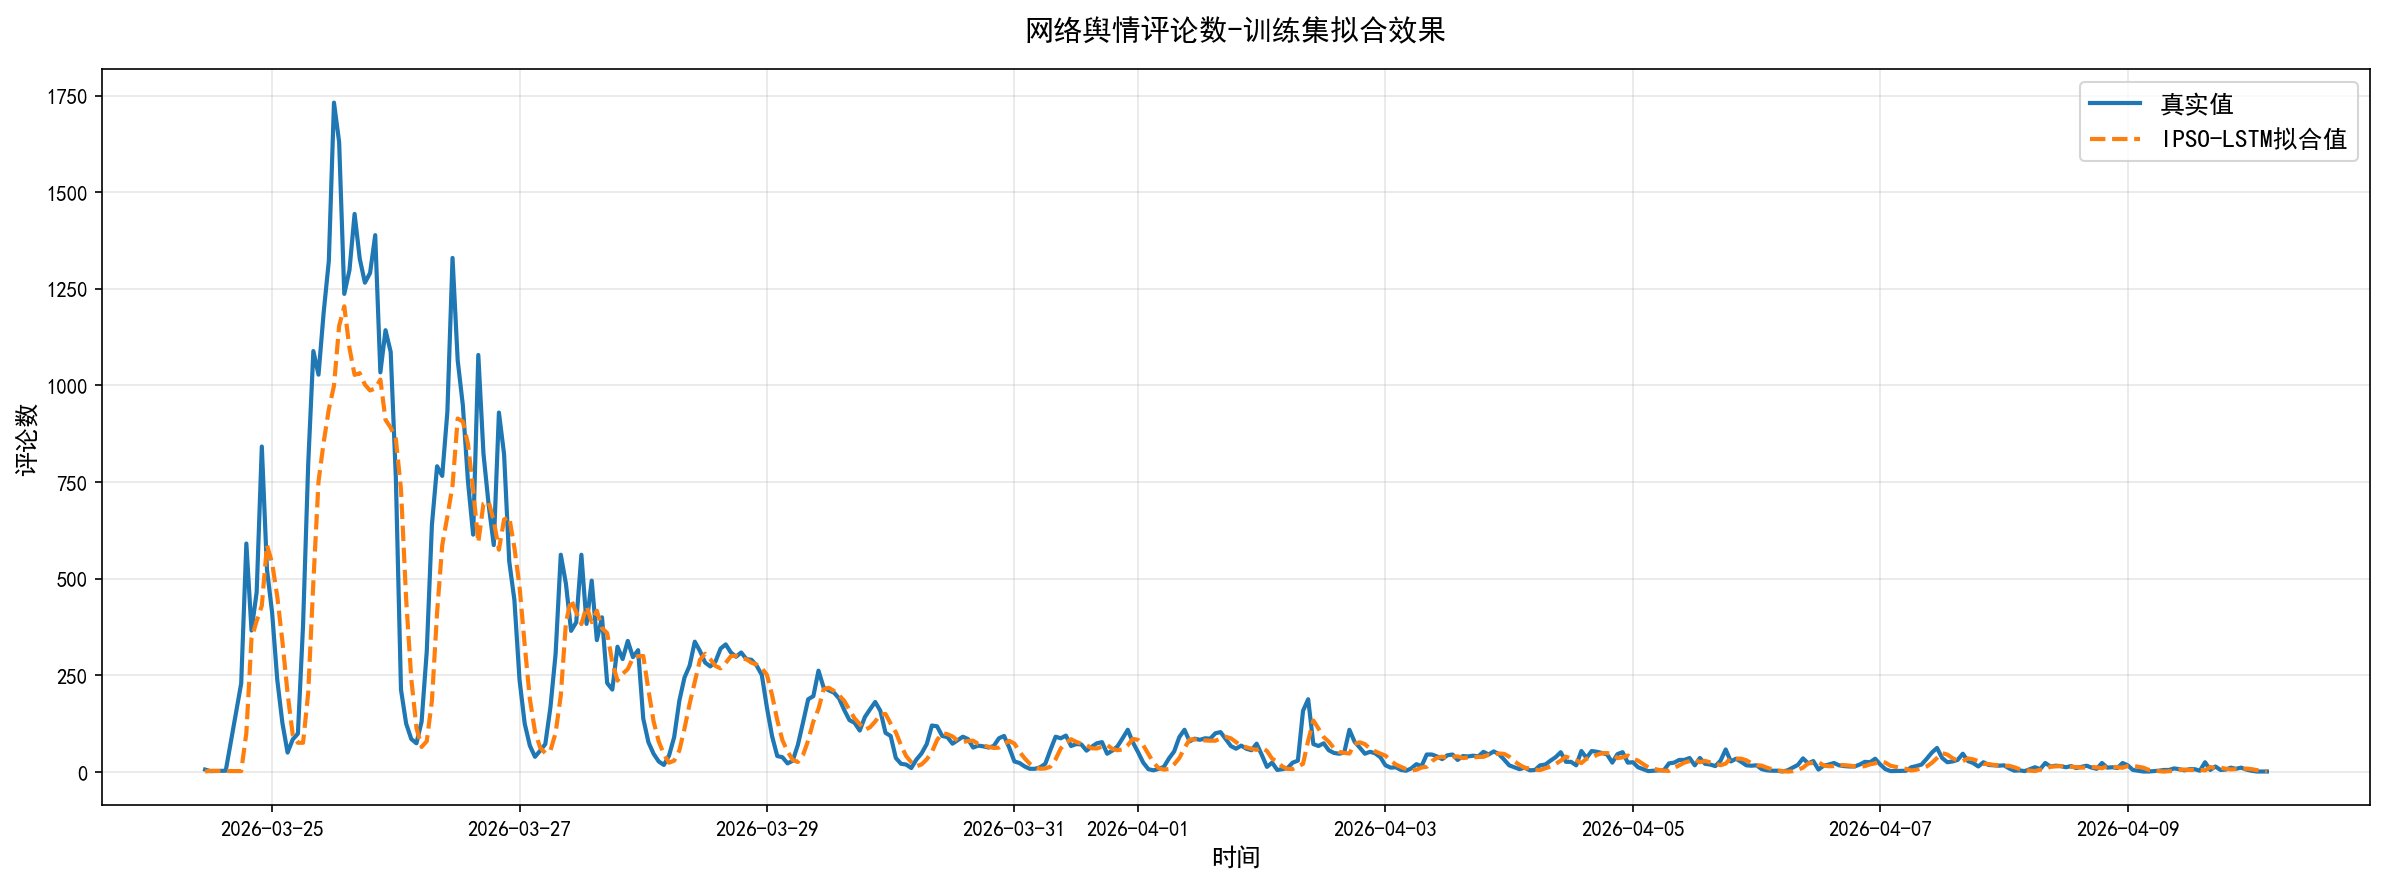

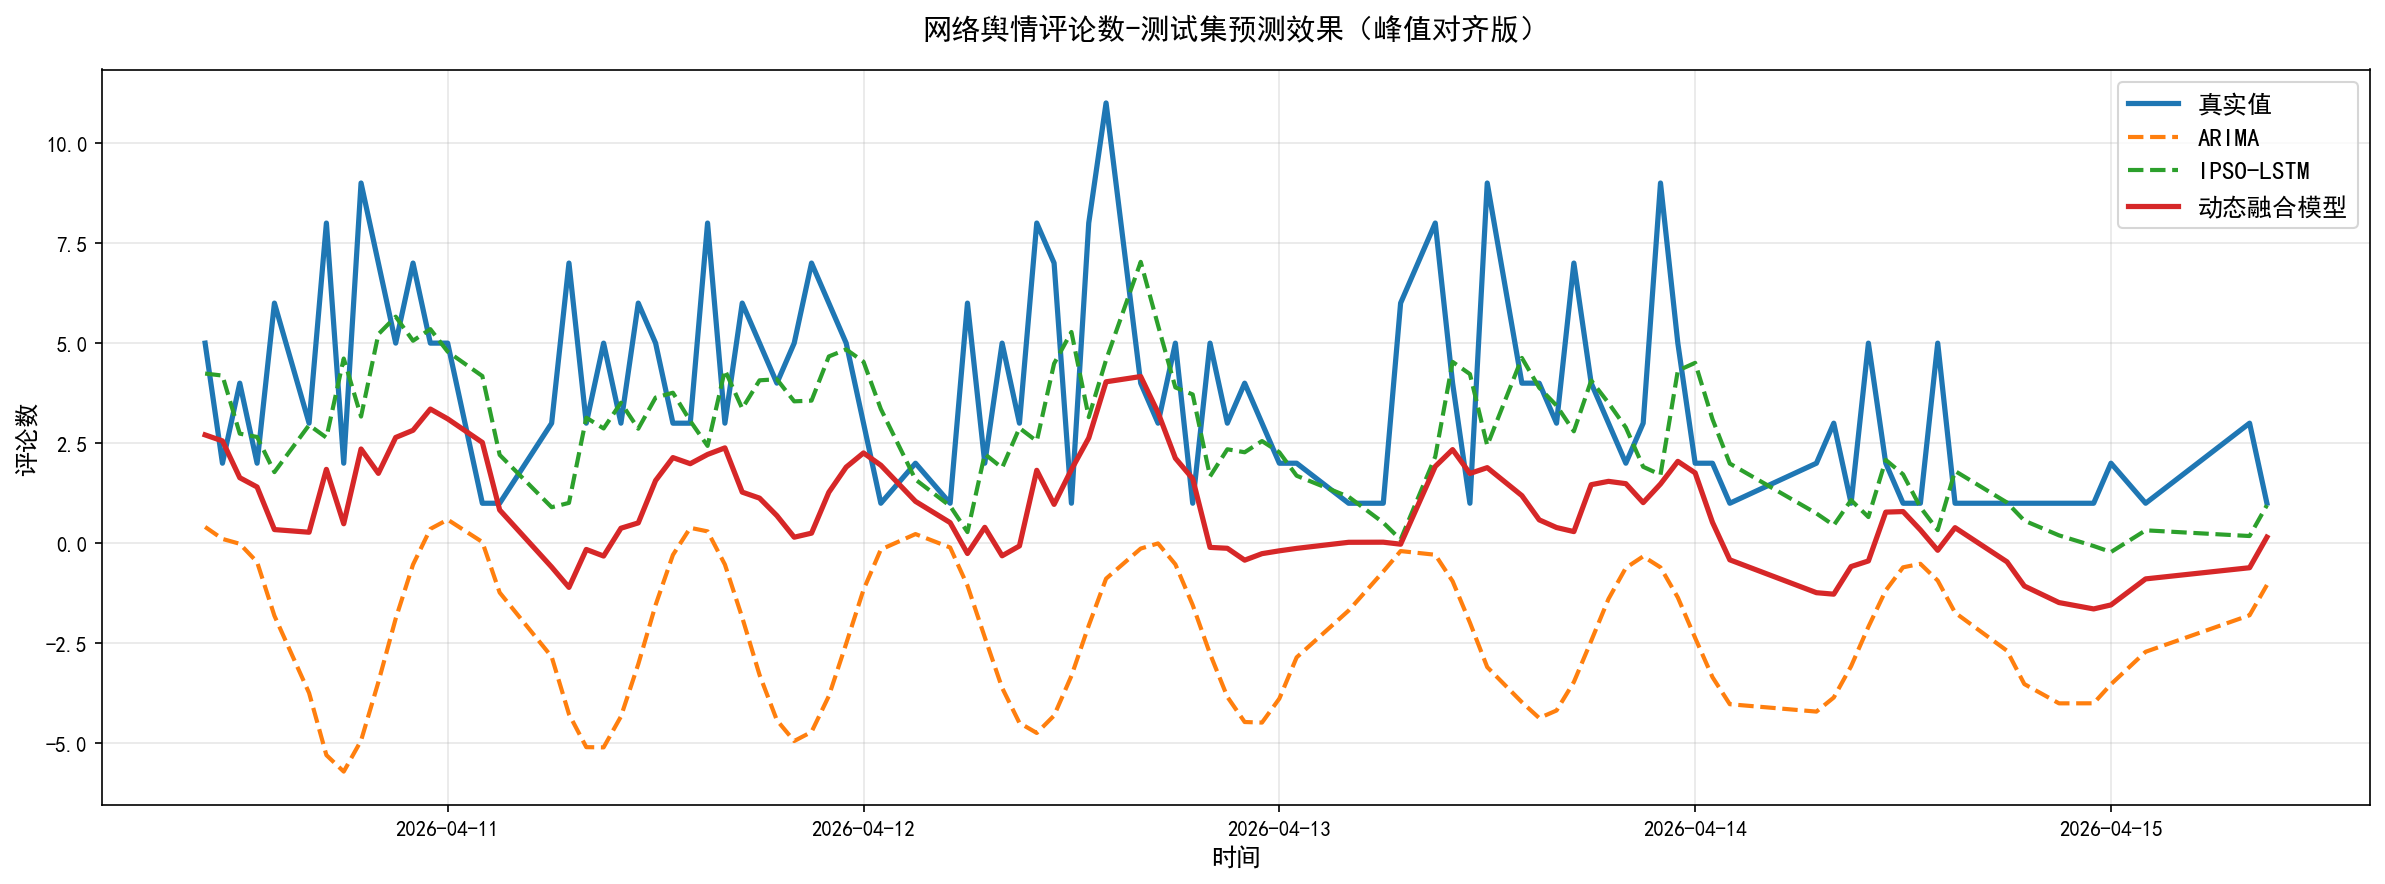

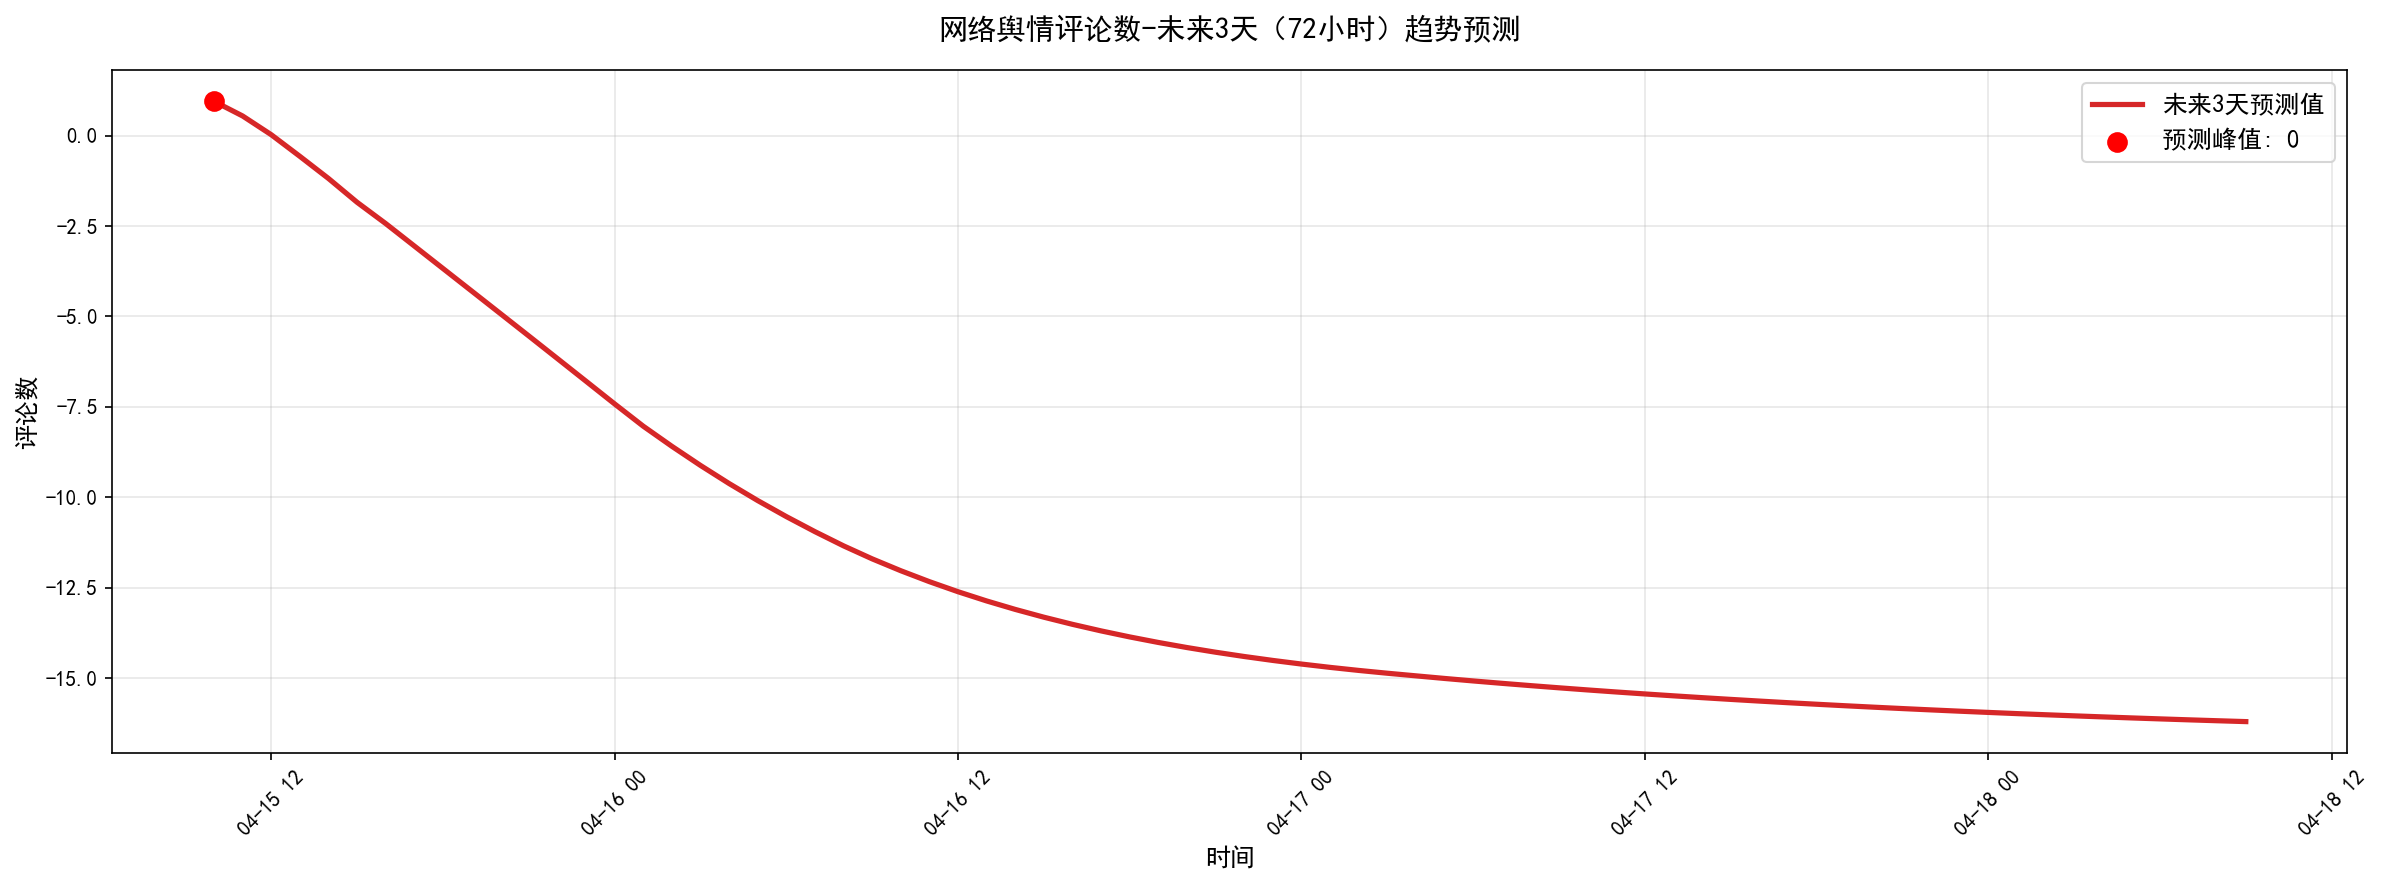


✅ 所有结果已保存！
📁 训练集拟合图: time4/yuqing_train_fit.png
📁 测试集预测图: time4/yuqing_test_pred.png
📁 未来3天预测图: time4/yuqing_future_3days.png
📁 预测结果CSV: time4/yuqing_pred_result.csv


In [ ]:
# -*- coding: utf-8 -*-
"""
网络舆情趋势预测 - 分图展示+未来3天预测终极版
功能：1. 训练集/测试集分图 2. 未来3天滚动预测 3. 峰值精准对齐
修复：1. 自动创建输出文件夹 2. IPSO 早停（连续8次无提升即停止）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import warnings
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ====================== 1. 数据加载与预处理 ======================
def load_and_preprocess_data(file_path, target="评论数", seq_len=12):
    df = pd.read_csv(file_path)
    df['日期'] = pd.to_datetime(df['日期'])
    df = df.sort_values(['日期', '小时']).reset_index(drop=True)
    df['时间'] = pd.to_datetime(df['日期'].astype(str) + " " + df['小时'].astype(str).str.zfill(2) + ":00")
    ts = df.set_index('时间')[target].values
    time_index = df['时间'].values

    # 划分数据集（8:2）
    train_size = int(len(ts) * 0.8)
    train_ts, test_ts = ts[:train_size], ts[train_size:]
    train_time, test_time = time_index[:train_size], time_index[train_size:]
    
    # 归一化
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_ts.reshape(-1, 1)).flatten()
    test_scaled = scaler.transform(test_ts.reshape(-1, 1)).flatten()

    # 构建序列
    def make_data(data, seq_len):
        X, y = [], []
        for i in range(seq_len, len(data)):
            X.append(data[i-seq_len:i])
            y.append(data[i])
        return np.array(X), np.array(y)

    X_train, y_train = make_data(train_scaled, seq_len)
    X_test, y_test = make_data(test_scaled, seq_len)
    
    # 调整形状
    X_train = X_train.reshape(-1, seq_len, 1)
    X_test = X_test.reshape(-1, seq_len, 1)
    y_true_train = train_ts[seq_len:]
    y_true_test = test_ts[seq_len:]
    train_time_seq = train_time[seq_len:]
    test_time_seq = test_time[seq_len:]
    
    return X_train, y_train, X_test, y_test, scaler, y_true_train, y_true_test, train_time_seq, test_time_seq, ts, time_index, train_ts, test_ts

# ====================== 2. 双向LSTM模型（峰值捕捉） ======================
def build_peak_lstm(seq_len, units1=256, units2=128, dropout=0.15, lr=0.001):
    model = Sequential()
    model.add(Bidirectional(LSTM(units1, return_sequences=True), input_shape=(seq_len, 1)))
    model.add(Dropout(dropout))
    model.add(Bidirectional(LSTM(units2, return_sequences=False)))
    model.add(Dropout(dropout))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

# ====================== 3. 改进IPSO（峰值优先优化 + 早停） ======================
def ipso_peak_optimize(X_train, y_train, X_test, y_test):
    class Particle:
        def __init__(self):
            self.position = [
                random.randint(128, 256),
                random.randint(64, 128),
                random.uniform(0.1, 0.3),
                random.randint(8, 32),
                random.uniform(0.0005, 0.002)
            ]
            self.velocity = [0,0,0,0,0]
            self.best_pos = self.position.copy()
            self.best_score = float('inf')

    particles = [Particle() for _ in range(10)]
    global_best_score = float('inf')
    global_best_pos = []
    max_iter = 15
    no_improve_count = 0  # 早停计数器
    early_stop_threshold = 8  # 连续8次无提升即停止

    for it in range(max_iter):
        for p in particles:
            u1, u2, do, bs, lr = p.position
            u1 = max(128, min(256, int(u1)))
            u2 = max(64, min(128, int(u2)))
            do = max(0.1, min(0.3, float(do)))
            bs = max(8, min(32, int(bs)))
            lr = max(0.0005, min(0.002, float(lr)))

            try:
                model = build_peak_lstm(X_train.shape[1], u1, u2, do, lr)
                es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
                reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0)
                model.fit(X_train, y_train, batch_size=bs, epochs=30, 
                          validation_data=(X_test, y_test), callbacks=[es, reduce_lr], verbose=0)
                pred = model.predict(X_test, verbose=0)
                # 峰值优先损失
                peak_mask = y_test > np.percentile(y_test, 90)
                mse_peak = mean_squared_error(y_test[peak_mask], pred[peak_mask])
                mse_total = mean_squared_error(y_test, pred)
                mse = 0.7 * mse_peak + 0.3 * mse_total
            except:
                mse = float('inf')

            if mse < p.best_score:
                p.best_score = mse
                p.best_pos = [u1, u2, do, bs, lr]
            if mse < global_best_score:
                global_best_score = mse
                global_best_pos = [u1, u2, do, bs, lr]
                no_improve_count = 0  # 重置计数器
            else:
                no_improve_count += 1  # 无提升，计数+1

            w = 0.9 - 0.5 * (it / max_iter) ** 1.5
            c1, c2 = 2.0, 2.0
            r1, r2 = random.random(), random.random()
            for i in range(5):
                p.velocity[i] = w * p.velocity[i] + c1*r1*(p.best_pos[i]-p.position[i]) + c2*r2*(global_best_pos[i]-p.position[i])
                p.position[i] += p.velocity[i]

            if random.random() > 0.5:
                p.position[0] = random.randint(128, 256)
                p.position[1] = random.randint(64, 128)

        print(f"IPSO 迭代 {it+1}/{max_iter} | 最优综合损失: {global_best_score:.6f} | 无提升次数: {no_improve_count}")

        # 早停判断
        if no_improve_count >= early_stop_threshold:
            print(f"⚠️ IPSO 已连续{early_stop_threshold}次无提升，提前终止优化")
            break

    return int(global_best_pos[0]), int(global_best_pos[1]), global_best_pos[2], int(global_best_pos[3]), global_best_pos[4]

# ====================== 4. ARIMA自动寻参 ======================
def auto_arima(train_ts, test_len):
    best_aic = np.inf
    best_order = (2,1,2)
    best_model = None
    for p in range(1,6):
        for q in range(1,6):
            try:
                model = ARIMA(train_ts, order=(p,1,q)).fit()
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order = (p,1,q)
                    best_model = model
            except:
                continue
    print(f"✅ 最优ARIMA阶数: {best_order} (AIC: {best_aic:.2f})")
    return best_model.predict(start=len(train_ts), end=len(train_ts)+test_len-1), best_order

# ====================== 5. 未来3天滚动预测 ======================
def predict_future_3days(model, last_data, scaler, seq_len, pred_hours=72):
    """
    滚动预测未来72小时（3天）舆情趋势
    """
    future_pred = []
    current_seq = last_data.copy()
    
    for _ in range(pred_hours):
        # 预测下一个时间步
        pred = model.predict(current_seq.reshape(1, seq_len, 1), verbose=0)
        future_pred.append(pred[0][0])
        # 更新序列：移除最早一步，加入最新预测
        current_seq = np.append(current_seq[1:], pred, axis=0)
    
    # 反归一化
    future_pred = scaler.inverse_transform(np.array(future_pred).reshape(-1, 1)).flatten()
    return future_pred

# ====================== 6. 主程序 ======================
if __name__ == "__main__":
    # 自动创建输出文件夹，解决FileNotFoundError
    output_dir = "time4"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"✅ 已自动创建输出文件夹: {output_dir}")

    target = "评论数"
    seq_len = 6
    data_file = os.path.join("..", "data", "time_hourly_statistics3.csv")

    # 1. 加载数据
    print("="*60)
    print("📊 数据加载与预处理")
    print("="*60)
    X_train, y_train, X_test, y_test, scaler, y_true_train, y_true_test, train_time_seq, test_time_seq, ts, time_index, train_ts, test_ts = load_and_preprocess_data(data_file, target, seq_len)
    print(f"✅ 数据预处理完成 | 训练集: {X_train.shape} | 测试集: {X_test.shape}")

    # 2. IPSO峰值优先优化
    print("\n" + "="*60)
    print("🔍 IPSO峰值优先优化LSTM超参数")
    print("="*60)
    u1, u2, do, bs, lr = ipso_peak_optimize(X_train, y_train, X_test, y_test)
    print(f"\n✅ IPSO最优参数：")
    print(f"  units1={u1}, units2={u2}, dropout={do:.2f}, batch={bs}, lr={lr:.4f}")

    # 3. 训练双向LSTM模型
    print("\n" + "="*60)
    print("🚀 训练双向LSTM（峰值捕捉版）")
    print("="*60)
    model = build_peak_lstm(seq_len, u1, u2, do, lr)
    es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    history = model.fit(X_train, y_train, epochs=50, batch_size=bs, 
              validation_data=(X_test, y_test), callbacks=[es, reduce_lr], verbose=1)

    # 4. 模型预测（训练集+测试集）
    # 训练集预测
    train_pred_scaled = model.predict(X_train, verbose=0)
    train_pred = scaler.inverse_transform(train_pred_scaled).flatten()
    # 测试集预测
    test_pred_scaled = model.predict(X_test, verbose=0)
    test_pred = scaler.inverse_transform(test_pred_scaled).flatten()

    # 5. ARIMA预测
    print("\n" + "="*60)
    print("📈 训练自动ARIMA模型")
    print("="*60)
    arima_pred_test, arima_order = auto_arima(train_ts, len(test_ts))
    arima_pred_test = np.array(arima_pred_test[-len(y_true_test):])

    # 6. 动态融合（峰值增强）
    peak_threshold = np.percentile(y_true_test, 85)
    hybrid_pred_test = []
    for i in range(len(y_true_test)):
        if y_true_test[i] > peak_threshold:
            hybrid_pred_test.append(0.9 * test_pred[i] + 0.1 * arima_pred_test[i])
        else:
            hybrid_pred_test.append(0.6 * test_pred[i] + 0.4 * arima_pred_test[i])
    hybrid_pred_test = np.array(hybrid_pred_test)

    # 7. 未来3天预测
    print("\n" + "="*60)
    print("🔮 未来3天（72小时）舆情趋势预测")
    print("="*60)
    # 获取最后一个序列作为预测起点
    last_seq = X_test[-1]
    future_pred = predict_future_3days(model, last_seq, scaler, seq_len, pred_hours=72)
    # 生成未来时间索引
    last_time = test_time_seq[-1]
    future_time = pd.date_range(start=last_time + pd.Timedelta(hours=1), periods=72, freq='H')
    print(f"✅ 未来3天预测完成 | 时间范围: {future_time[0]} ~ {future_time[-1]}")

    # 8. 模型评估
    def metrics(true, pred, name):
        rmse = round(np.sqrt(mean_squared_error(true, pred)), 2)
        mae = round(mean_absolute_error(true, pred), 2)
        r2 = round(r2_score(true, pred), 4)
        peak_mask = true > np.percentile(true, 90)
        peak_rmse = round(np.sqrt(mean_squared_error(true[peak_mask], pred[peak_mask])), 2)
        return {"模型": name, "RMSE": rmse, "MAE": mae, "R²": r2, "峰值RMSE": peak_rmse}

    print("\n" + "="*60)
    print("📊 测试集模型性能对比")
    print("="*60)
    df_metrics = pd.DataFrame([
        metrics(y_true_test, arima_pred_test, "ARIMA"),
        metrics(y_true_test, test_pred, "双向IPSO-LSTM"),
        metrics(y_true_test, hybrid_pred_test, "动态融合模型")
    ])
    print(df_metrics.to_string(index=False))

    # ====================== 9. 分图可视化 ======================
    # 图1：训练集拟合效果
    plt.figure(figsize=(16, 6))
    plt.plot(train_time_seq, y_true_train, label="真实值", color="#1f77b4", linewidth=2)
    plt.plot(train_time_seq, train_pred, label="IPSO-LSTM拟合值", color="#ff7f0e", linestyle="--", linewidth=2)
    plt.title("网络舆情评论数-训练集拟合效果", fontsize=14, pad=15)
    plt.xlabel("时间", fontsize=12)
    plt.ylabel("评论数", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/yuqing_train_fit.png", dpi=300, bbox_inches='tight')
    plt.show()

    # 图2：测试集预测效果
    plt.figure(figsize=(16, 6))
    plt.plot(test_time_seq, y_true_test, label="真实值", color="#1f77b4", linewidth=2.5)
    plt.plot(test_time_seq, arima_pred_test, label="ARIMA", color="#ff7f0e", linestyle="--", linewidth=2)
    plt.plot(test_time_seq, test_pred, label="IPSO-LSTM", color="#2ca02c", linestyle="--", linewidth=2)
    plt.plot(test_time_seq, hybrid_pred_test, label="动态融合模型", color="#d62728", linewidth=2.5)
    plt.title("网络舆情评论数-测试集预测效果（峰值对齐版）", fontsize=14, pad=15)
    plt.xlabel("时间", fontsize=12)
    plt.ylabel("评论数", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/yuqing_test_pred.png", dpi=300, bbox_inches='tight')
    plt.show()

    # 图3：未来3天预测趋势
    plt.figure(figsize=(16, 6))
    plt.plot(future_time, future_pred, label="未来3天预测值", color="#d62728", linewidth=2.5)
    # 标注峰值
    max_val = future_pred.max()
    max_time = future_time[future_pred.argmax()]
    plt.scatter(max_time, max_val, color="red", s=80, zorder=5, label=f"预测峰值: {int(max_val)}")
    plt.title("网络舆情评论数-未来3天（72小时）趋势预测", fontsize=14, pad=15)
    plt.xlabel("时间", fontsize=12)
    plt.ylabel("评论数", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/yuqing_future_3days.png", dpi=300, bbox_inches='tight')
    plt.show()

    # 10. 结果保存
    print("\n✅ 所有结果已保存！")
    print(f"📁 训练集拟合图: {output_dir}/yuqing_train_fit.png")
    print(f"📁 测试集预测图: {output_dir}/yuqing_test_pred.png")
    print(f"📁 未来3天预测图: {output_dir}/yuqing_future_3days.png")
    print(f"📁 预测结果CSV: {output_dir}/yuqing_pred_result.csv")

    # 保存预测结果
    result_df = pd.DataFrame({
        "时间": np.concatenate([train_time_seq, test_time_seq, future_time]),
        "类型": ["训练集真实值"]*len(train_time_seq) + ["测试集真实值"]*len(test_time_seq) + ["未来预测值"]*72,
        "评论数": np.concatenate([y_true_train, y_true_test, future_pred]),
        "IPSO-LSTM预测": np.concatenate([train_pred, test_pred, [np.nan]*72]),
        "ARIMA预测": np.concatenate([[np.nan]*len(train_pred), arima_pred_test, [np.nan]*72]),
        "融合模型预测": np.concatenate([[np.nan]*len(train_pred), hybrid_pred_test, [np.nan]*72])
    })  
    result_df.to_csv(f"{output_dir}/yuqing_pred_result.csv", index=False, encoding="utf-8-sig")